<a href="https://colab.research.google.com/github/invadoli/Projekti3_ML_DL/blob/main/ML_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("balraj98/duts-saliency-detection-dataset")

Using Colab cache for faster access to the 'duts-saliency-detection-dataset' dataset.


In [2]:
import os
print(os.listdir(path))

['DUTS-TE', 'metadata.csv', 'DUTS-TR']


In [3]:
%cd Projekti3ML_DL/


/content/Projekti3ML_DL


In [4]:
import importlib
import data_loader
import sod_model

importlib.reload(data_loader)
importlib.reload(sod_model)
from data_loader import DUTSDataset
from sod_model import SODModel

print("Data Loader reloaded successfully!")

Data Loader reloaded successfully!


In [5]:
import torch
from torch.utils.data import DataLoader, random_split
from sod_model import SODModel
from data_loader import DUTSDataset
from train import train_one_epoch
from evaluate import calculate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
import os

img_dir = os.path.join(path, 'DUTS-TR', 'DUTS-TR-Image')
mask_dir = os.path.join(path, 'DUTS-TR', 'DUTS-TR-Mask')

dataset = DUTSDataset(img_dir=img_dir, mask_dir=mask_dir)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

print(f"Dataset loaded successfully with {len(dataset)} images.")

Dataset loaded successfully with 10553 images.


In [7]:
model = SODModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
for epoch in range(15):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    print(f"Epoch {epoch+1}/15 | Loss: {loss:.4f}")

Epoch 1/15 | Loss: 0.8872
Epoch 2/15 | Loss: 0.8469
Epoch 3/15 | Loss: 0.8313
Epoch 4/15 | Loss: 0.8232
Epoch 5/15 | Loss: 0.8193
Epoch 6/15 | Loss: 0.8143
Epoch 7/15 | Loss: 0.8108
Epoch 8/15 | Loss: 0.8068
Epoch 9/15 | Loss: 0.8051
Epoch 10/15 | Loss: 0.8045
Epoch 11/15 | Loss: 0.8018
Epoch 12/15 | Loss: 0.7981
Epoch 13/15 | Loss: 0.7976
Epoch 14/15 | Loss: 0.7956
Epoch 15/15 | Loss: 0.7919


In [9]:
import importlib
import evaluate
importlib.reload(evaluate)
from evaluate import calculate_metrics

In [10]:
model.eval()

metrics_totals = {"precision": 0, "recall": 0, "f1": 0, "iou": 0}

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)

        p, r, f1, iou = calculate_metrics(preds, masks, threshold=0.6)

        metrics_totals["precision"] += p
        metrics_totals["recall"] += r
        metrics_totals["f1"] += f1
        metrics_totals["iou"] += iou

num_batches = len(val_loader)
print("--- Final Validation Metrics ---")
print(f"Precision: {metrics_totals['precision']/num_batches:.4f}")
print(f"Recall:    {metrics_totals['recall']/num_batches:.4f}")
print(f"F1 Score:  {metrics_totals['f1']/num_batches:.4f}")
print(f"IoU:       {metrics_totals['iou']/num_batches:.4f}")

--- Final Validation Metrics ---
Precision: 0.6838
Recall:    0.4235
F1 Score:  0.5177
IoU:       0.3527


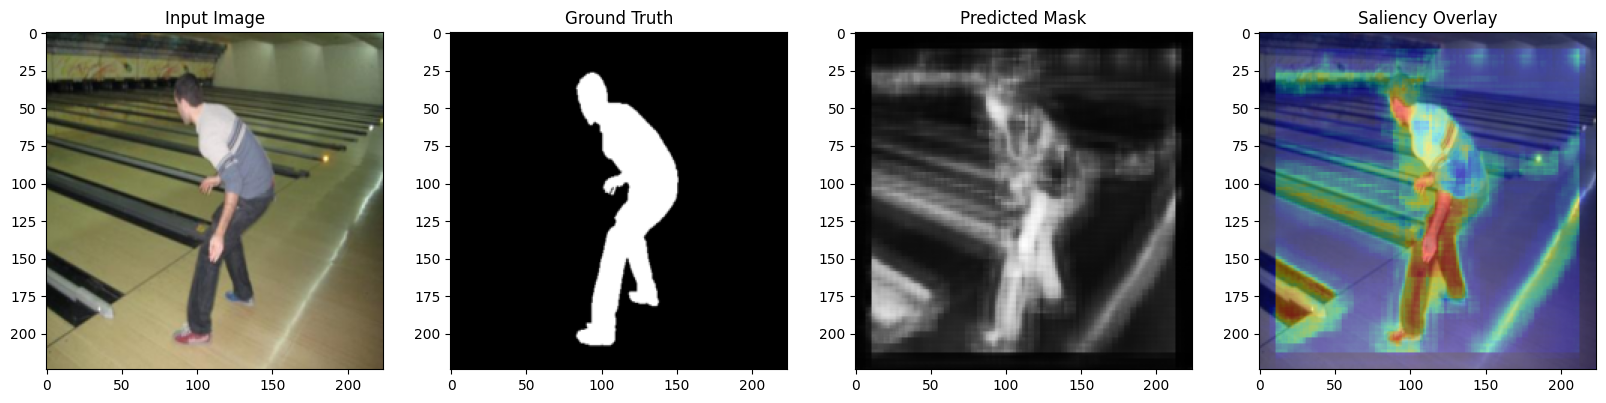

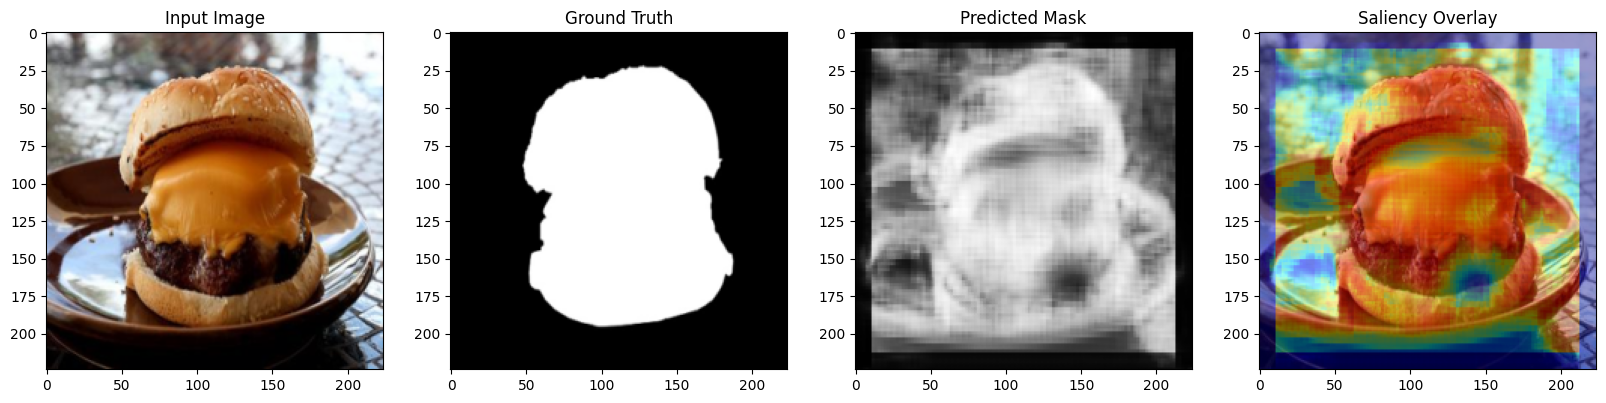

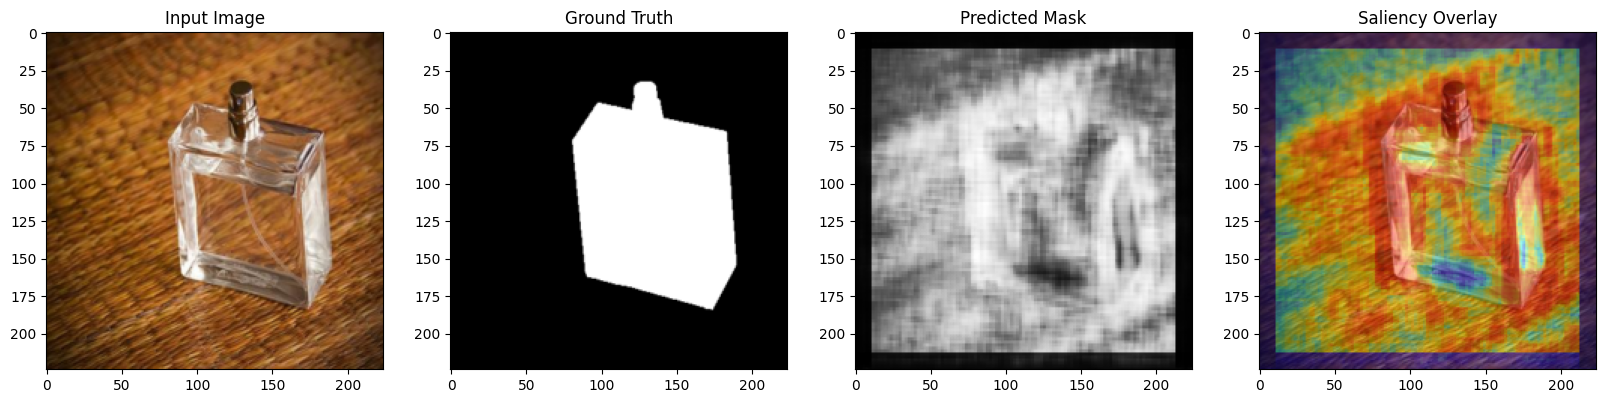

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_saliency(model, dataset, idx=0):
    model.eval()
    image, mask = dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(input_tensor).squeeze(0).cpu().numpy()[0]

    img_show = image.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(img_show); ax[0].set_title("Input Image")
    ax[1].imshow(mask.squeeze(), cmap='gray'); ax[1].set_title("Ground Truth")
    ax[2].imshow(prediction, cmap='gray'); ax[2].set_title("Predicted Mask")

    ax[3].imshow(img_show)
    ax[3].imshow(prediction, cmap='jet', alpha=0.4)
    ax[3].set_title("Saliency Overlay")
    plt.show()

for i in range(3):
    visualize_saliency(model, val_ds, idx=i)